## **Raw Data → Split → Train Model → Predict → Evaluate → Plot**

*Underfitting* : Modèle trop simple qui ne capture pas les patterns.  
`ex:Tu n’as pas assez appris (tu échoues à l’examen).`  
*Overfitting* : Modèle trop complexe qui mémorise les données au lieu d’apprendre.  
`ex:Tu as mémorisé les questions d’un ancien examen par cœur, mais tu ne comprends pas le sujet (tu échoues si les questions changent).`

In [33]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [34]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from multiprocessing import Pool

**make_classification**: Generates a synthetic dataset for classification.
**train_test_split**: Splits the dataset into training and testing sets.
**accuracy_score**: Calculates the accuracy of the model.
**DecisionTreeClassifier**: The machine learning model we are using.
**Pool**: Used for parallel processing


Data Generation:

In [36]:
X, y = make_classification(n_samples=9000, n_features=18, n_informative=4, n_redundant=2, random_state=1)

Splitting the Data:

 Si on teste le modèle sur les mêmes données qu’on a utilisées pour l’entraîner, il peut juste mémoriser les réponses au lieu d’apprendre des règles générales (c’est ce qu’on appelle le overfitting).
 On veut un modèle qui fonctionne bien même sur des données qu’il n’a jamais vues.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
#(e.g., 0.3 means 30% test, 70% train)

`X_test` is what you feed into the model to get predictions.  
`y_test` is what you compare the predictions  to calculate accuracy.


Training and Evaluating the Model:

In [38]:
#Create empty lists to store training and testing accuracies.
train_scores, test_scores = list(), list()
values = [i for i in range(1, 21)]#list comprehension

Model Training Loop:

In [ ]:
values = list(range(1, 21))
train_scores = []
test_scores = []

for i in values:
    # Train
    model = DecisionTreeClassifier(max_depth=i)
    model.fit(X_train, y_train)
    
    # Evaluate
    train_pred = model.predict(X_train)# ask model about what it STUDIED
    test_pred = model.predict(X_test)#ask model about what it NEVER SAW
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    print(f'Max Depth: {i}, Train Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}')
    
    train_scores.append(train_acc)  # appends 20 times
    test_scores.append(test_acc)    # appends 20 times

Max Depth: 1, Train Acc: 0.750, Test Acc: 0.744
Max Depth: 2, Train Acc: 0.868, Test Acc: 0.871
Max Depth: 3, Train Acc: 0.892, Test Acc: 0.892
Max Depth: 4, Train Acc: 0.905, Test Acc: 0.907
Max Depth: 5, Train Acc: 0.927, Test Acc: 0.922
Max Depth: 6, Train Acc: 0.939, Test Acc: 0.931
Max Depth: 7, Train Acc: 0.953, Test Acc: 0.936
Max Depth: 8, Train Acc: 0.963, Test Acc: 0.940
Max Depth: 9, Train Acc: 0.974, Test Acc: 0.947
Max Depth: 10, Train Acc: 0.979, Test Acc: 0.949
Max Depth: 11, Train Acc: 0.983, Test Acc: 0.943
Max Depth: 12, Train Acc: 0.987, Test Acc: 0.941
Max Depth: 13, Train Acc: 0.990, Test Acc: 0.941
Max Depth: 14, Train Acc: 0.993, Test Acc: 0.937
Max Depth: 15, Train Acc: 0.994, Test Acc: 0.940
Max Depth: 16, Train Acc: 0.995, Test Acc: 0.936
Max Depth: 17, Train Acc: 0.995, Test Acc: 0.936
Max Depth: 18, Train Acc: 0.996, Test Acc: 0.936
Max Depth: 19, Train Acc: 0.997, Test Acc: 0.934
Max Depth: 20, Train Acc: 0.997, Test Acc: 0.938


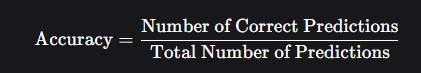

**train_acc** : Montre comment le modèle performe sur les données qu’il a déjà vues (entraînement).  
**test_acc** : Montre comment le modèle performe sur des données inédites (test)  
  
Si **train_acc** est très élevée mais **test_acc** est basse → Overfitting (le modèle a mémorisé les données d’entraînement).  
Si les deux sont proches et élevées → Bon modèle (il généralise bien)


In [48]:
print(len(values))
print(len(train_scores))
print(len(test_scores))

20
20
20


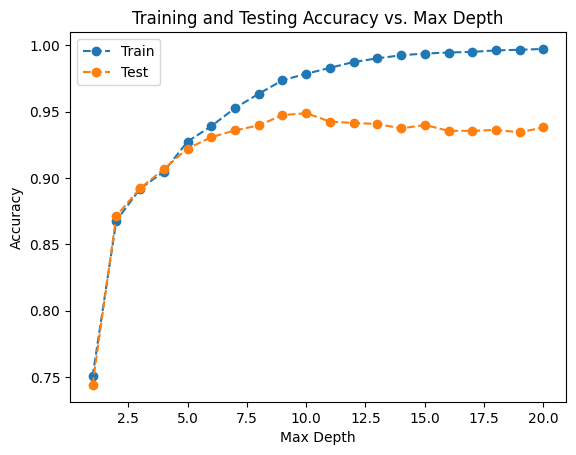

In [49]:
# Plot the training and testing accuracy scores
import matplotlib.pyplot as plt

plt.plot(values, train_scores, '--o', label='Train')
plt.plot(values, test_scores, '--o', label='Test')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy vs. Max Depth')
plt.legend()
plt.show()